In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, optimizers, losses

In [18]:
# Hyperparameters
batch_size = 32  # Increased for stability
block_size = 32  # Context length
max_epochs = 5000  # Increased for better training
learning_rate = 1e-3
n_embd = 64  # Increased capacity
n_head = 4  # More heads
n_layer = 4  # More layers
dropout = 0.0

In [19]:
# Step 1: Load the data (hardcoded conversational snippet, repeated more for larger dataset)
text = """First Citizen:
Before we proceed any further, hear you this.

Second Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.
""" * 100  # Increased to ~60k characters

# Lowercase to fix missing uppercase chars in vocab
text = text.lower()

In [20]:
# Step 2: Cleaning the data (build char-level tokenizer)
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

In [21]:
# Convert text to numpy array (TF uses numpy for datasets)
data = np.array(encode(text), dtype=np.int32)

# Step 3: Split the data
n = int(0.9 * len(data))  # 90% train, 10% val
train_data = data[:n]
val_data = data[n:]

In [22]:
# Dataset generator
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = np.random.randint(len(data) - block_size, size=batch_size)
    x = np.stack([data[i:i+block_size] for i in ix])
    y = np.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

In [23]:
# Custom Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim)]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs, use_causal_mask=True)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [24]:
# GPT Model
class GPT(Model):
    def __init__(self):
        super(GPT, self).__init__()
        self.token_embedding = layers.Embedding(vocab_size, n_embd)
        self.position_embedding = layers.Embedding(block_size, n_embd)
        self.blocks = [TransformerBlock(n_embd, n_head, n_embd * 4, dropout) for _ in range(n_layer)]
        self.ln_f = layers.LayerNormalization(epsilon=1e-6)
        self.head = layers.Dense(vocab_size)

    def call(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(tf.range(T))
        x = tok_emb + pos_emb
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        if targets is None:
            return logits
        else:
            loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
            return logits, loss(targets, logits)

    def generate(self, idx, max_new_tokens, temperature=0.8):  # Added temperature for better sampling
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits = self(idx_cond)
            logits = logits[:, -1, :]
            logits = logits / temperature  # Apply temperature
            probs = tf.nn.softmax(logits, axis=-1)
            idx_next = tf.cast(tf.random.categorical(tf.math.log(probs), num_samples=1), tf.int32)
            idx = tf.concat([idx, idx_next], axis=1)
        return idx

In [25]:
# Initialize model and optimizer
model = GPT()
optimizer = optimizers.Adam(learning_rate=learning_rate)

In [26]:
# Compile for training (custom loop for loss)
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits, loss_value = model(x, y)
    grads = tape.gradient(loss_value, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss_value

In [27]:
%%time

# Step 4: Train the model
train_losses = []
for epoch in range(max_epochs):
    xb, yb = get_batch('train')
    loss = train_step(xb, yb)
    train_losses.append(loss.numpy())
    if epoch % 500 == 0 or epoch == max_epochs - 1:  # Print less frequently
        print(f"Epoch {epoch}: Training loss {loss.numpy():.4f}")

Epoch 0: Training loss 4.1005
Epoch 500: Training loss 0.1698
Epoch 1000: Training loss 0.1523
Epoch 1500: Training loss 0.1390
Epoch 2000: Training loss 0.1348
Epoch 2500: Training loss 0.1346
Epoch 3000: Training loss 0.1305
Epoch 3500: Training loss 0.1395
Epoch 4000: Training loss 0.1053
Epoch 4500: Training loss 0.1336
Epoch 4999: Training loss 0.1199
CPU times: user 20min, sys: 1min 41s, total: 21min 42s
Wall time: 5min 8s


In [28]:
# Step 5: Evaluate the performance
def estimate_loss(split, eval_iters=20):
    losses = []
    for _ in range(eval_iters):
        x, y = get_batch(split)
        _, loss = model(x, y)
        losses.append(loss.numpy())
    return np.mean(losses)

In [29]:
train_loss = estimate_loss('train')
val_loss = estimate_loss('val')
print(f"Final train loss: {train_loss:.4f}")
print(f"Final val loss: {val_loss:.4f}")
perplexity = np.exp(val_loss)
print(f"Perplexity: {perplexity:.4f}")

Final train loss: 0.1271
Final val loss: 0.1265
Perplexity: 1.1348


In [30]:
# Generate text examples (single-turn chatbot)
prompt = "user: what is the price of corn?\nbot:\n"  # Already lowercase
context = np.array([encode(prompt)], dtype=np.int32)
generated = model.generate(tf.constant(context), max_new_tokens=100, temperature=0.8)
generated_text = prompt + decode(generated.numpy()[0, len(encode(prompt)):].tolist())
print("Generated conversational text:")
print(generated_text)

Generated conversational text:
user: what is the price of corn?
bot:
we are accounted poor citizens, the patricians good.
what authority surfeits on would relieve us: if


In [31]:
prompt2 = "user: who are the patricians?\nbot:\n"  # Already lowercase
context2 = np.array([encode(prompt2)], dtype=np.int32)
generated2 = model.generate(tf.constant(context2), max_new_tokens=100, temperature=0.8)
generated_text2 = prompt2 + decode(generated2.numpy()[0, len(encode(prompt2)):].tolist())
print("Another generated text:")
print(generated_text2)

Another generated text:
user: who are the patricians?
bot:
what authority surfeits on would relieve us: if they
would yield us but the superfluity, while it we


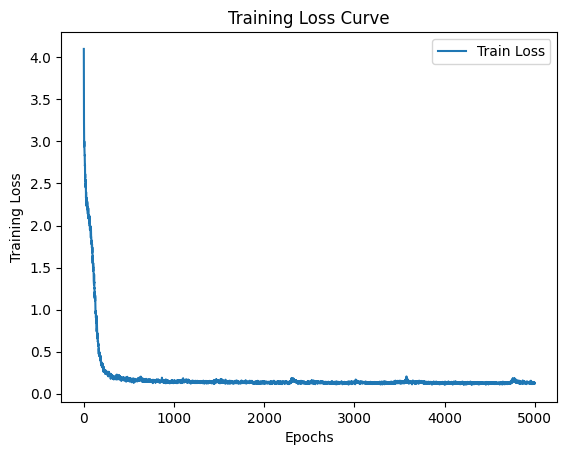

In [ ]:
# For graphs: Plot loss curve
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Training Loss Curve')
plt.show()